# WGAN-GP - CelebA Face Generation

This project implements a Wasserstein Generative Adversarial Network with Gradient Penalty (WGAN-GP) to generate synthetic 64×64 RGB face images using the CelebA dataset.

The project extends the earlier DCGAN work by replacing the conventional binary-classification GAN objective with the Wasserstein objective and gradient penalty. The notebook focuses on adversarial training stability, generator and critic design, generated-image progression, latent-space interpolation, and qualitative evaluation.

Runtime: Google Colab
Recommended GPU: NVIDIA Tesla T4
Image resolution: 64 × 64 RGB


In [ ]:
!pip uninstall -y tensorflow-datasets tfds-nightly -q
!pip install -q tensorflow-datasets==4.9.10 importlib_resources

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 22.6 MB/s eta 0:00:00


## 1. Import Required Libraries

Load TensorFlow, NumPy, Matplotlib, and TensorFlow Datasets.

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices("GPU")))
if tf.config.list_physical_devices("GPU"):
    print("GPU:", tf.config.list_physical_devices("GPU")[0])


TensorFlow Version: 2.20.0
Num GPUs Available: 1
GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## 2. Configure Reproducibility and Training

Set seeds and define the latent dimension, image size, batch size, epochs, optimizer settings, critic update ratio, and gradient-penalty coefficient.

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

LATENT_DIM = 128
IMAGE_SIZE = 64
CHANNELS = 3

BATCH_SIZE = 64
EPOCHS = 50

GENERATOR_LEARNING_RATE = 1e-4
CRITIC_LEARNING_RATE = 1e-4

BETA_1 = 0.0
BETA_2 = 0.9

CRITIC_STEPS = 5
GRADIENT_PENALTY_WEIGHT = 10.0

SAMPLE_COUNT = 16
SAMPLE_INTERVAL = 5

print("Latent Dimension:", LATENT_DIM)
print("Image Shape:", (IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
print("Batch Size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Generator Learning Rate:", GENERATOR_LEARNING_RATE)
print("Critic Learning Rate:", CRITIC_LEARNING_RATE)
print("Critic Steps:", CRITIC_STEPS)
print("Gradient Penalty Weight:", GRADIENT_PENALTY_WEIGHT)


Latent Dimension: 128
Image Shape: (64, 64, 3)
Batch Size: 64
Epochs: 50
Generator Learning Rate: 0.0001
Critic Learning Rate: 0.0001
Critic Steps: 5
Gradient Penalty Weight: 10.0


## 3. Load the CelebA Dataset

Load the CelebA training split through TensorFlow Datasets. The GAN uses face images only and does not use identity or attribute labels.

In [ ]:
celeba_train = tfds.load(
    "celeb_a",
    split="train",
    shuffle_files=True,
    as_supervised=False,
    download=True
)

print("CelebA dataset loaded.")
print(celeba_train)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/celeb_a/incomplete.HBRPOI_2.1.0/celeb_a-train.tfrecord-[0-9][0-9][0-9][0-9…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/celeb_a/incomplete.HBRPOI_2.1.0/celeb_a-validation.tfrecord-[0-9][0-9][0-9…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/celeb_a/incomplete.HBRPOI_2.1.0/celeb_a-test.tfrecord-[0-9][0-9][0-9][0-9]…

Dataset celeb_a downloaded and prepared to /root/tensorflow_datasets/celeb_a/2.1.0. Subsequent calls will reuse this data.
CelebA dataset loaded.
<_PrefetchDataset element_spec={'attributes': {'5_o_Clock_Shadow': TensorSpec(shape=(), dtype=tf.bool, name=None), 'Arched_Eyebrows': TensorSpec(shape=(), dtype=tf.bool, name=None), 'Attractive': TensorSpec(shape=(), dtype=tf.bool, name=None), 'Bags_Under_Eyes': TensorSpec(shape=(), dtype=tf.bool, name=None), 'Bald': TensorSpec(shape=(), dtype=tf.bool, name=None), 'Bangs': TensorSpec(shape=(), dtype=tf.bool, name=None), 'Big_Lips': TensorSpec(shape=(), dtype=tf.bool, name=None), 'Big_Nose': TensorSpec(shape=(), dtype=tf.bool, name=None), 'Black_Hair': TensorSpec(shape=(), dtype=tf.bool, name=None), 'Blond_Hair': TensorSpec(shape=(), dtype=tf.bool, name=None), 'Blurry': TensorSpec(shape=(), dtype=tf.bool, name=None), 'Brown_Hair': TensorSpec(shape=(), dtype=tf.bool, name=None), 'Bushy_Eyebrows': TensorSpec(shape=(), dtype=tf.bool, name=None), 

## 4. Inspect the Dataset

Verify the original image dimensions and display representative face images.

Original Batch Shape: (16, 218, 178, 3)
Original Image Shape: (218, 178, 3)


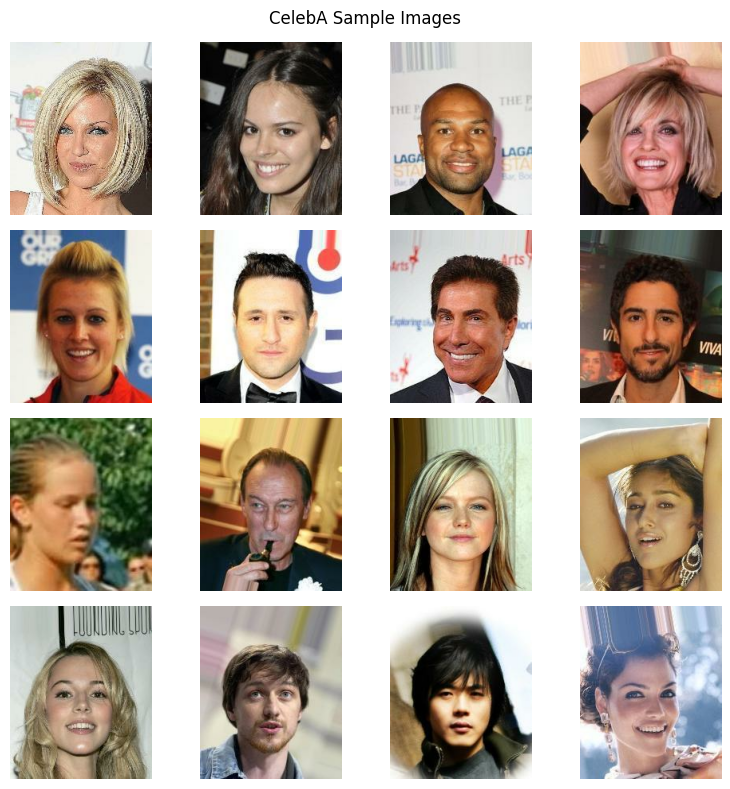

In [ ]:
sample_batch = next(
    iter(
        celeba_train.batch(16)
    )
)

sample_images = sample_batch["image"].numpy()

print("Original Batch Shape:", sample_images.shape)
print("Original Image Shape:", sample_images[0].shape)

plt.figure(figsize=(8, 8))

for index in range(16):
    plt.subplot(4, 4, index + 1)
    plt.imshow(sample_images[index])
    plt.axis("off")

plt.suptitle("CelebA Sample Images")
plt.tight_layout()
plt.show()


## 5. Preprocess the Images

Resize faces to 64×64 RGB and normalize pixel values to [-1, 1] for the generator's tanh output.

In [ ]:
def preprocess_image(example):
    image = tf.image.resize(
        example["image"],
        [IMAGE_SIZE, IMAGE_SIZE]
    )
    image = tf.cast(image, tf.float32)
    image = (image - 127.5) / 127.5
    return image

train_dataset = (
    celeba_train
    .map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .shuffle(
        10000,
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .batch(
        BATCH_SIZE,
        drop_remainder=True
    )
    .prefetch(tf.data.AUTOTUNE)
)

sample_preprocessed = next(iter(train_dataset))

print("Preprocessed Batch Shape:", sample_preprocessed.shape)
print("Minimum Value:", float(tf.reduce_min(sample_preprocessed)))
print("Maximum Value:", float(tf.reduce_max(sample_preprocessed)))


Preprocessed Batch Shape: (64, 64, 64, 3)
Minimum Value: -1.0
Maximum Value: 1.0


## 6. Build the Generator

Build a convolutional generator that maps latent vectors to 64×64 RGB images.

In [ ]:
def build_generator():
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(LATENT_DIM,)),
            tf.keras.layers.Dense(4 * 4 * 1024, use_bias=False),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Reshape((4, 4, 1024)),

            tf.keras.layers.Conv2DTranspose(
                512, 4, strides=2, padding="same", use_bias=False
            ),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),

            tf.keras.layers.Conv2DTranspose(
                256, 4, strides=2, padding="same", use_bias=False
            ),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),

            tf.keras.layers.Conv2DTranspose(
                128, 4, strides=2, padding="same", use_bias=False
            ),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),

            tf.keras.layers.Conv2DTranspose(
                CHANNELS, 4, strides=2, padding="same", activation="tanh"
            )
        ],
        name="generator"
    )
    return model

generator = build_generator()

test_noise = tf.random.normal([1, LATENT_DIM], seed=SEED)
test_generated = generator(test_noise, training=False)

print("Generator Output Shape:", test_generated.shape)


Generator Output Shape: (1, 64, 64, 3)


## 7. Build the Critic

Build a critic that outputs a real-valued score instead of a probability.

In [ ]:
def build_critic():
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(
                shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
            ),

            tf.keras.layers.Conv2D(
                64, 4, strides=2, padding="same"
            ),
            tf.keras.layers.LeakyReLU(negative_slope=0.2),

            tf.keras.layers.Conv2D(
                128, 4, strides=2, padding="same"
            ),
            tf.keras.layers.LayerNormalization(),
            tf.keras.layers.LeakyReLU(negative_slope=0.2),

            tf.keras.layers.Conv2D(
                256, 4, strides=2, padding="same"
            ),
            tf.keras.layers.LayerNormalization(),
            tf.keras.layers.LeakyReLU(negative_slope=0.2),

            tf.keras.layers.Conv2D(
                512, 4, strides=2, padding="same"
            ),
            tf.keras.layers.LayerNormalization(),
            tf.keras.layers.LeakyReLU(negative_slope=0.2),

            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(1)
        ],
        name="critic"
    )
    return model

critic = build_critic()

test_score = critic(test_generated, training=False)
print("Critic Output Shape:", test_score.shape)


Critic Output Shape: (1, 1)


## 8. Inspect the Model Architectures

Print model summaries and verify output shapes.

In [ ]:
print("===== GENERATOR =====")
generator.summary()

print("\n===== CRITIC =====")
critic.summary()


===== GENERATOR =====


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16384)          │     2,097,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16384)          │        65,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 512)      │     8,388,608 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 256)    │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 3)      │         6,147 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,182,467 (50.29 MB)

 Trainable params: 13,147,907 (50.16 MB)

...

Model: "critic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 16, 16, 128)    │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 8, 8, 256)      │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 512)      │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 4, 4, 512)      │         1,024 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,766,529 (10.55 MB)

 Trainable params: 2,766,529 (10.55 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Define the WGAN-GP Objective

Define Wasserstein losses, gradient penalty, and Adam optimizers.

In [ ]:
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=GENERATOR_LEARNING_RATE,
    beta_1=BETA_1,
    beta_2=BETA_2
)

critic_optimizer = tf.keras.optimizers.Adam(
    learning_rate=CRITIC_LEARNING_RATE,
    beta_1=BETA_1,
    beta_2=BETA_2
)

def generator_loss(fake_scores):
    return -tf.reduce_mean(fake_scores)

def critic_loss(real_scores, fake_scores):
    return (
        tf.reduce_mean(fake_scores)
        - tf.reduce_mean(real_scores)
    )

def gradient_penalty(real_images, fake_images):
    batch_size = tf.shape(real_images)[0]

    alpha = tf.random.uniform(
        [batch_size, 1, 1, 1],
        0.0,
        1.0
    )

    interpolated = (
        alpha * real_images
        + (1.0 - alpha) * fake_images
    )

    with tf.GradientTape() as tape:
        tape.watch(interpolated)

        interpolated_scores = critic(
            interpolated,
            training=True
        )

    gradients = tape.gradient(
        interpolated_scores,
        interpolated
    )

    gradients = tf.reshape(
        gradients,
        [batch_size, -1]
    )

    gradient_norm = tf.sqrt(
        tf.reduce_sum(
            tf.square(gradients),
            axis=1
        ) + 1e-12
    )

    return tf.reduce_mean(
        tf.square(
            gradient_norm - 1.0
        )
    )

print("WGAN-GP objective and optimizers are ready.")


WGAN-GP objective and optimizers are ready.


## 10. Define the WGAN-GP Training Steps

Implement critic updates, gradient-penalty calculation, and generator updates.

In [ ]:
@tf.function
def critic_train_step(real_images):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as tape:
        fake_images = generator(noise, training=True)

        real_scores = critic(
            real_images,
            training=True
        )

        fake_scores = critic(
            fake_images,
            training=True
        )

        w_loss = critic_loss(
            real_scores,
            fake_scores
        )

        gp = gradient_penalty(
            real_images,
            fake_images
        )

        total_loss = (
            w_loss
            + GRADIENT_PENALTY_WEIGHT * gp
        )

    gradients = tape.gradient(
        total_loss,
        critic.trainable_variables
    )

    critic_optimizer.apply_gradients(
        zip(
            gradients,
            critic.trainable_variables
        )
    )

    return total_loss, w_loss, gp


@tf.function
def generator_train_step():
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as tape:
        fake_images = generator(
            noise,
            training=True
        )

        fake_scores = critic(
            fake_images,
            training=True
        )

        g_loss = generator_loss(
            fake_scores
        )

    gradients = tape.gradient(
        g_loss,
        generator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gradients,
            generator.trainable_variables
        )
    )

    return g_loss


fixed_noise = tf.random.normal(
    [SAMPLE_COUNT, LATENT_DIM],
    seed=SEED
)

print("WGAN-GP training functions are ready.")


WGAN-GP training functions are ready.


## 11. Train the WGAN-GP

Train the model and save fixed-noise samples at checkpoints.

In [ ]:
progress_epochs = []
progress_images = []

generator_losses = []
critic_losses = []
wasserstein_losses = []
gradient_penalties = []

for epoch in range(1, EPOCHS + 1):

    epoch_g = []
    epoch_c = []
    epoch_w = []
    epoch_gp = []

    for real_images in train_dataset:

        for _ in range(CRITIC_STEPS):
            c_loss, w_loss, gp = critic_train_step(
                real_images
            )

            epoch_c.append(float(c_loss))
            epoch_w.append(float(w_loss))
            epoch_gp.append(float(gp))

        g_loss = generator_train_step()
        epoch_g.append(float(g_loss))

    mean_g = np.mean(epoch_g)
    mean_c = np.mean(epoch_c)
    mean_w = np.mean(epoch_w)
    mean_gp = np.mean(epoch_gp)

    generator_losses.append(mean_g)
    critic_losses.append(mean_c)
    wasserstein_losses.append(mean_w)
    gradient_penalties.append(mean_gp)

    if (
        epoch == 1
        or epoch % SAMPLE_INTERVAL == 0
        or epoch == EPOCHS
    ):
        generated = generator(
            fixed_noise,
            training=False
        ).numpy()

        progress_epochs.append(epoch)
        progress_images.append(generated)

    print(
        f"Epoch {epoch:03d}/{EPOCHS} | "
        f"Generator Loss: {mean_g:.4f} | "
        f"Critic Loss: {mean_c:.4f} | "
        f"Wasserstein Loss: {mean_w:.4f} | "
        f"Gradient Penalty: {mean_gp:.4f}"
    )

print("WGAN-GP training completed.")


Epoch 001/50 | Generator Loss: 12.4736 | Critic Loss: -10.6100 | Wasserstein Loss: -13.3358 | Gradient Penalty: 0.2726
Epoch 002/50 | Generator Loss: -26.5114 | Critic Loss: -4.9367 | Wasserstein Loss: -5.9828 | Gradient Penalty: 0.1046
Epoch 003/50 | Generator Loss: -47.1439 | Critic Loss: -3.9750 | Wasserstein Loss: -4.7345 | Gradient Penalty: 0.0759
Epoch 004/50 | Generator Loss: -89.5434 | Critic Loss: -3.4802 | Wasserstein Loss: -4.1173 | Gradient Penalty: 0.0637
Epoch 005/50 | Generator Loss: -112.7855 | Critic Loss: -3.1947 | Wasserstein Loss: -3.8211 | Gradient Penalty: 0.0626
Epoch 006/50 | Generator Loss: -204.2472 | Critic Loss: -1.1502 | Wasserstein Loss: -1.7372 | Gradient Penalty: 0.0587
Epoch 007/50 | Generator Loss: -263.1213 | Critic Loss: -0.5424 | Wasserstein Loss: -1.1211 | Gradient Penalty: 0.0579


KeyboardInterrupt: 

## 12. Visualize Training Progress

Plot generator, critic, Wasserstein, and gradient-penalty curves and show generated faces.

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(
    range(1, EPOCHS + 1),
    generator_losses,
    label="Generator Loss"
)
plt.plot(
    range(1, EPOCHS + 1),
    critic_losses,
    label="Critic Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("WGAN-GP Training Losses")
plt.legend()
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(
    range(1, EPOCHS + 1),
    wasserstein_losses,
    label="Wasserstein Loss"
)
plt.plot(
    range(1, EPOCHS + 1),
    gradient_penalties,
    label="Gradient Penalty"
)
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("WGAN-GP Training Components")
plt.legend()
plt.show()

for epoch, images in zip(
    progress_epochs,
    progress_images
):
    plt.figure(figsize=(8, 8))

    for index in range(SAMPLE_COUNT):
        plt.subplot(4, 4, index + 1)

        image = (
            images[index] * 127.5
            + 127.5
        )

        image = np.clip(
            image,
            0,
            255
        ).astype("uint8")

        plt.imshow(image)
        plt.axis("off")

    plt.suptitle(
        f"Generated Faces - Epoch {epoch}"
    )
    plt.tight_layout()
    plt.show()


## 13. Evaluate Final Generated Faces

Generate a larger final image grid for qualitative assessment.

In [ ]:
final_noise = tf.random.normal(
    [64, LATENT_DIM],
    seed=SEED + 100
)

final_images = generator(
    final_noise,
    training=False
).numpy()

plt.figure(figsize=(10, 10))

for index in range(64):
    plt.subplot(8, 8, index + 1)

    image = (
        final_images[index] * 127.5
        + 127.5
    )

    image = np.clip(
        image,
        0,
        255
    ).astype("uint8")

    plt.imshow(image)
    plt.axis("off")

plt.suptitle(
    "Final WGAN-GP Generated Faces"
)
plt.tight_layout()
plt.show()

print(
    "Final Generated Tensor Shape:",
    final_images.shape
)


## 14. Latent Space Interpolation

Interpolate between latent vectors to inspect smooth changes in generated faces.

In [ ]:
def interpolate_latent_vectors(
    vector_a,
    vector_b,
    steps=10
):
    alphas = np.linspace(
        0.0,
        1.0,
        steps
    )

    return np.stack(
        [
            (1.0 - alpha) * vector_a
            + alpha * vector_b
            for alpha in alphas
        ]
    )

latent_a = tf.random.normal(
    [LATENT_DIM],
    seed=SEED + 1
)

latent_b = tf.random.normal(
    [LATENT_DIM],
    seed=SEED + 2
)

interpolated_vectors = (
    interpolate_latent_vectors(
        latent_a.numpy(),
        latent_b.numpy(),
        steps=10
    )
)

interpolated_images = generator(
    tf.convert_to_tensor(
        interpolated_vectors,
        dtype=tf.float32
    ),
    training=False
).numpy()

plt.figure(figsize=(15, 6))

for index, image in enumerate(
    interpolated_images
):
    plt.subplot(2, 5, index + 1)

    image = (
        image * 127.5
        + 127.5
    )

    image = np.clip(
        image,
        0,
        255
    ).astype("uint8")

    plt.imshow(image)
    plt.axis("off")

plt.suptitle(
    "WGAN-GP Latent Space Interpolation"
)
plt.tight_layout()
plt.show()


## 15. Fixed-Noise Comparison

Generate a repeatable set of final faces from fixed latent vectors.

In [ ]:
comparison_images = generator(
    fixed_noise,
    training=False
).numpy()

plt.figure(figsize=(8, 8))

for index in range(SAMPLE_COUNT):
    plt.subplot(4, 4, index + 1)

    image = (
        comparison_images[index] * 127.5
        + 127.5
    )

    image = np.clip(
        image,
        0,
        255
    ).astype("uint8")

    plt.imshow(image)
    plt.axis("off")

plt.suptitle(
    "Fixed Latent Samples from Final Generator"
)
plt.tight_layout()
plt.show()


## 16. Key Findings



## 17. Conclusion

